<a href="https://colab.research.google.com/github/RubaEgbaria/Esch-Crowd-Monitoring/blob/master/people_counter_from_vid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## The code counts people detected in video frames by identifying green bounding boxes and aggregates results per frame and per second, saving statistics to JSON.

The code excpects an annotated video.

### An exmaple of a frame from a vid:

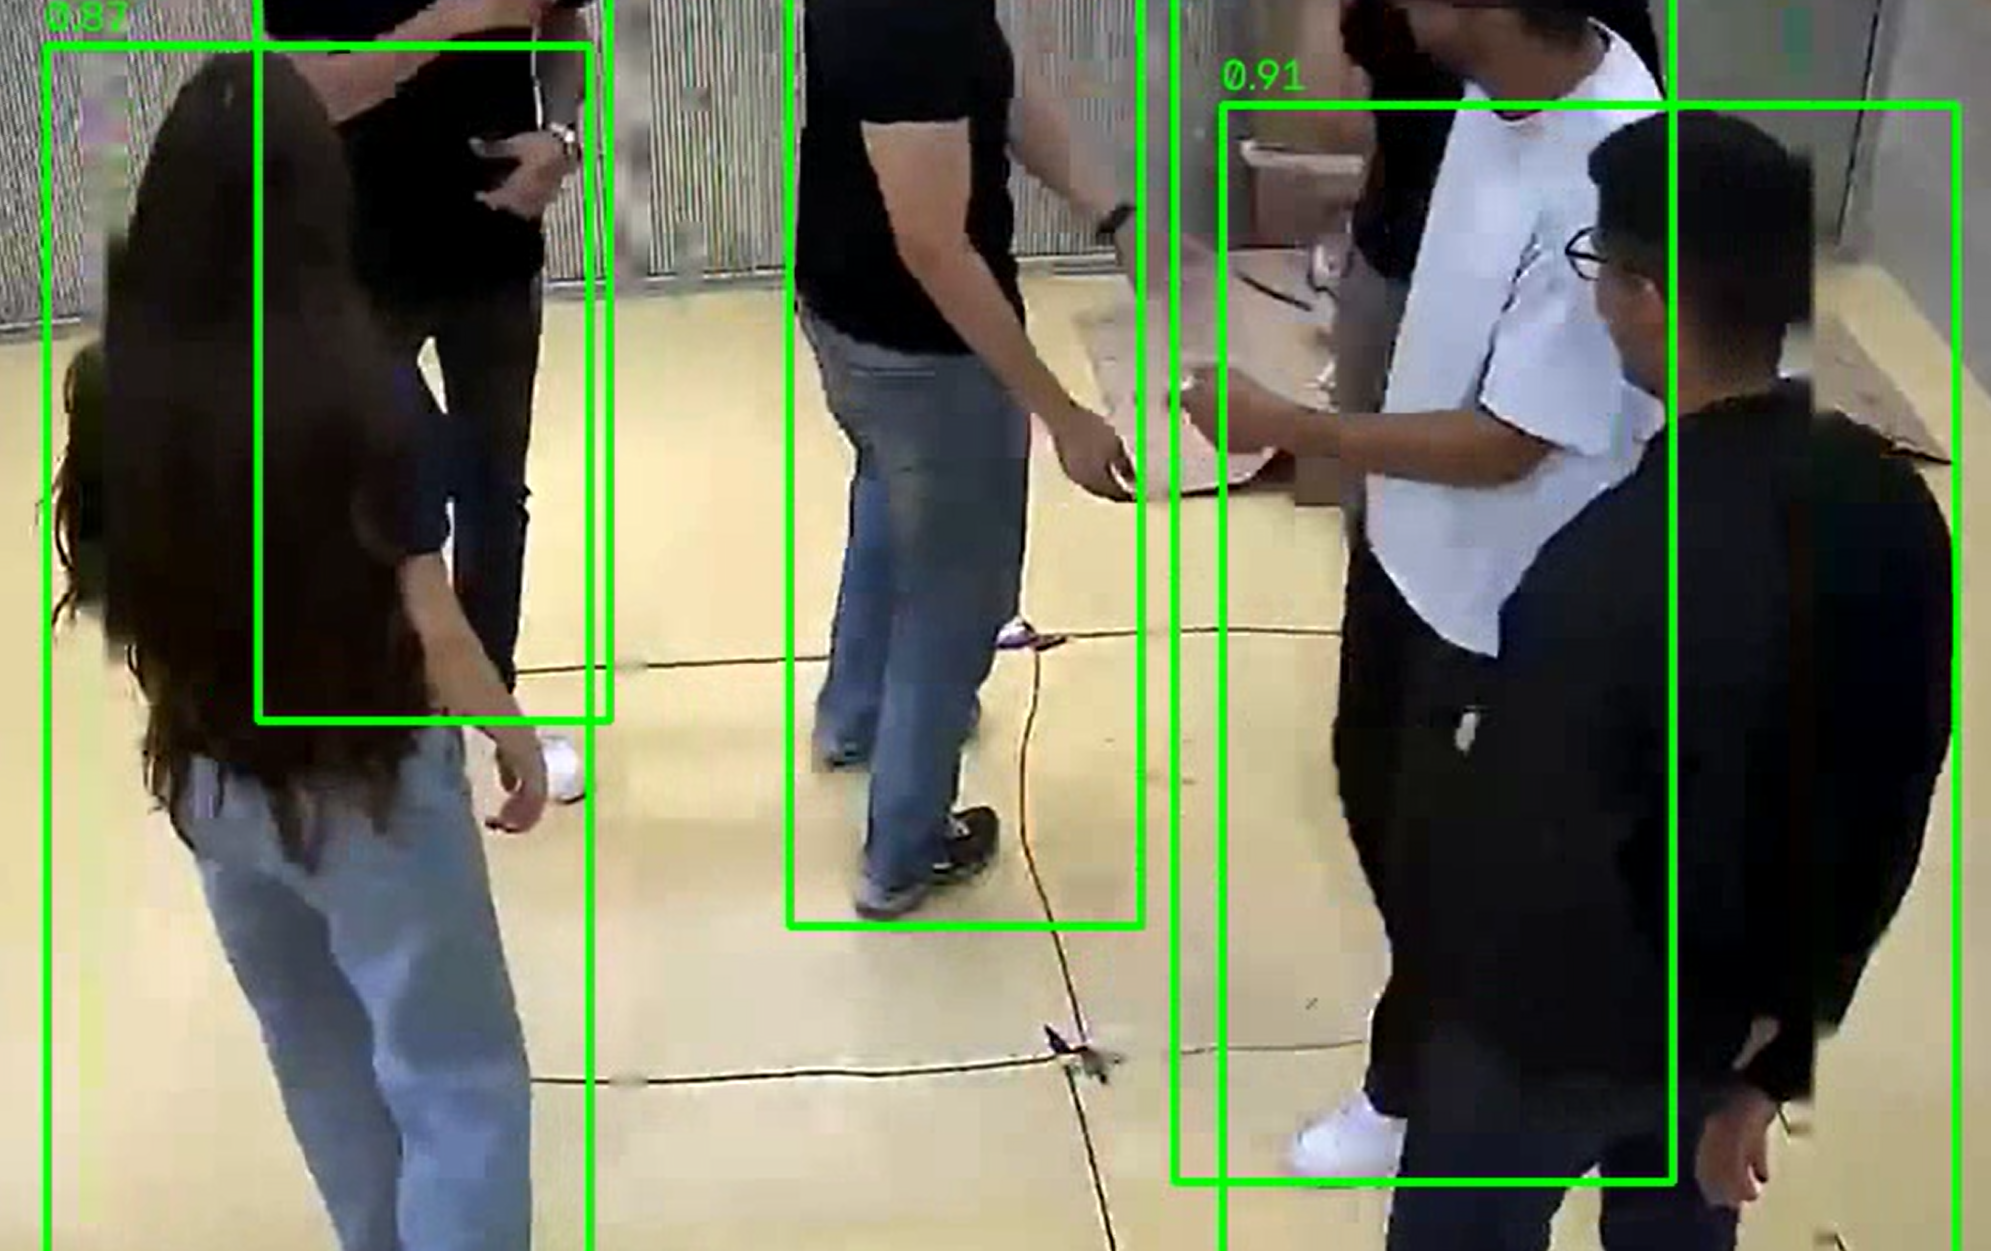

In [1]:
import cv2
import numpy as np
from collections import defaultdict
import json

class PeopleCounter:
    def __init__(self, video_path, output_path='detection_counts.json'):
        """
        Initialize the people counter

        Args:
            video_path: Path to the video file
            output_path: Path to save detection results
        """
        self.video_path = video_path
        self.output_path = output_path
        self.cap = cv2.VideoCapture(video_path)
        self.fps = self.cap.get(cv2.CAP_PROP_FPS)
        self.total_frames = int(self.cap.get(cv2.CAP_PROP_FRAME_COUNT))

        # Detection results
        self.detections = defaultdict(list)  # frame_number -> count
        self.per_second = defaultdict(list)  # second -> list of counts per frame

    def detect_green_boxes(self, frame, lower_green=None, upper_green=None):
        """
        Detect green bounding boxes in frame

        Args:
            frame: Current frame
            lower_green: Lower HSV bounds for green (default tuned for typical detection green)
            upper_green: Upper HSV bounds for green

        Returns:
            Number of green boxes detected, list of box coordinates
        """
        if lower_green is None:
            lower_green = np.array([35, 40, 40])
            upper_green = np.array([85, 255, 255])

        if upper_green is None:
            upper_green = np.array([85, 255, 255])

        # Convert to HSV for better color detection
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

        # Create mask for green color
        mask = cv2.inRange(hsv, lower_green, upper_green)

        # Morphological operations to clean up mask
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

        # Find contours
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Filter contours by area (remove noise)
        min_area = 100
        max_area = 100000

        valid_boxes = []
        for contour in contours:
            area = cv2.contourArea(contour)
            if min_area < area < max_area:
                x, y, w, h = cv2.boundingRect(contour)
                valid_boxes.append((x, y, w, h))

        return len(valid_boxes), valid_boxes, mask

    def process_video(self, save_frames_with_counts=False, output_dir='./frames_with_counts'):
        """
        Process entire video and count detections

        Args:
            save_frames_with_counts: If True, saves frames with count annotations
            output_dir: Directory to save annotated frames
        """
        frame_count = 0

        print(f"Processing video: {self.video_path}")
        print(f"Total frames: {self.total_frames}")
        print(f"FPS: {self.fps}")

        while True:
            ret, frame = self.cap.read()

            if not ret:
                break

            # Detect people (green boxes)
            count, boxes, mask = self.detect_green_boxes(frame)

            # Store results
            self.detections[frame_count] = count
            second = frame_count / self.fps
            self.per_second[int(second)].append(count)

            # save annotated frame
            if save_frames_with_counts:
                annotated_frame = frame.copy()
                # Draw boxes
                for (x, y, w, h) in boxes:
                    cv2.rectangle(annotated_frame, (x, y), (x+w, y+h), (0, 255, 0), 2)

                # Add count text
                cv2.putText(annotated_frame, f"Count: {count}", (10, 30),
                           cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
                cv2.putText(annotated_frame, f"Frame: {frame_count}", (10, 70),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

                cv2.imwrite(f"{output_dir}/frame_{frame_count:06d}.png", annotated_frame)

            frame_count += 1

            if frame_count % 100 == 0:
                print(f"Processed {frame_count}/{self.total_frames} frames")

        self.cap.release()
        print(f"Processing complete. Total frames: {frame_count}")

    def get_statistics(self):
        """
        Calculate statistics for ground truth comparison
        """
        all_counts = list(self.detections.values())

        stats = {
            'total_frames': len(all_counts),
            'total_detections': sum(all_counts),
            'average_per_frame': np.mean(all_counts),
            'median_per_frame': np.median(all_counts),
            'max_detections': max(all_counts),
            'min_detections': min(all_counts),
            'std_dev': np.std(all_counts),
            'per_second_summary': {}
        }

        # Per-second statistics
        for second, counts in sorted(self.per_second.items()):
            stats['per_second_summary'][second] = {
                'frame_count': len(counts),
                'total_detections': sum(counts),
                'average': np.mean(counts),
                'frames_detail': counts
            }

        return stats

    def save_results(self):
        """
        Save detection results to JSON file
        """
        stats = self.get_statistics()

        output_data = {
            'statistics': stats,
            'per_frame': dict(self.detections),
            'per_second': {k: v for k, v in sorted(self.per_second.items())}
        }

        with open(self.output_path, 'w') as f:
            json.dump(output_data, f, indent=2)

        print(f"Results saved to {self.output_path}")

        return output_data

    def print_summary(self):
        """
        Print summary statistics
        """
        stats = self.get_statistics()

        print("\n" + "="*60)
        print("DETECTION SUMMARY")
        print("="*60)
        print(f"Total Frames: {stats['total_frames']}")
        print(f"Total Detections: {stats['total_detections']}")
        print(f"Average per Frame: {stats['average_per_frame']:.2f}")
        print(f"Median per Frame: {stats['median_per_frame']:.2f}")
        print(f"Max Detections: {stats['max_detections']}")
        print(f"Min Detections: {stats['min_detections']}")
        print(f"Std Dev: {stats['std_dev']:.2f}")
        print("="*60)

        print("\nPER SECOND BREAKDOWN:")
        print("-"*60)
        for second, data in sorted(stats['per_second_summary'].items()):
            print(f"Second {second}: Total={data['total_detections']}, "
                  f"Avg={data['average']:.2f}, Frames={data['frame_count']}")
        print("="*60 + "\n")

In [2]:
counter = PeopleCounter('WhatsApp Video 2026-09-10 at 13.56.14.mp4')
counter.process_video()
results = counter.save_results()
counter.print_summary()

counter.process_video(save_frames_with_counts=True)

stats = counter.get_statistics()
print(stats['total_detections'])


Processing video: WhatsApp Video 2026-09-10 at 13.56.14.mp4
Total frames: 454
FPS: 10.520624131005716
Processed 100/454 frames
Processed 200/454 frames
Processed 300/454 frames
Processed 400/454 frames
Processing complete. Total frames: 454
Results saved to detection_counts.json

DETECTION SUMMARY
Total Frames: 454
Total Detections: 802
Average per Frame: 1.77
Median per Frame: 1.00
Max Detections: 7
Min Detections: 0
Std Dev: 1.59

PER SECOND BREAKDOWN:
------------------------------------------------------------
Second 0: Total=5, Avg=0.45, Frames=11
Second 1: Total=13, Avg=1.18, Frames=11
Second 2: Total=11, Avg=1.10, Frames=10
Second 3: Total=17, Avg=1.55, Frames=11
Second 4: Total=10, Avg=1.00, Frames=10
Second 5: Total=14, Avg=1.27, Frames=11
Second 6: Total=4, Avg=0.40, Frames=10
Second 7: Total=31, Avg=2.82, Frames=11
Second 8: Total=31, Avg=3.10, Frames=10
Second 9: Total=51, Avg=4.64, Frames=11
Second 10: Total=46, Avg=4.60, Frames=10
Second 11: Total=31, Avg=2.82, Frames=11
